# DS06 · Probability, conditional evidence, and base rates

<!-- paper-first -->
### Research question

**Reading:** [PM03](../../curriculum/papers/modeling.md#pm03). Review the assigned figure or result before starting the lesson.

**Question:** Would the same model score imply the same risk in a population with a different outcome frequency?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Format:** 75–100 minutes of guided work, plus 30–60 minutes in the assigned existing course material. **Prerequisite:** the foundations notebooks; follow this strand in order. The core exercise is synthetic, offline, and independently runnable. It demonstrates mechanics, not a validated participant-data analysis.

## Existing course material

Read [Data 8: Making decisions (Bayes and rare-event prediction)](https://github.com/data-8/textbook/blob/5235b7653f8dfaeb90e43419b9aa069322f2d60b/chapters/18/2/Making_Decisions.ipynb). Use the indicated topic, then return here to apply it to a neuroimaging question. Berkeley material is linked in its original form, not adapted or redistributed; its CC BY-NC-ND terms remain upstream. Neuromatch material is CC BY 4.0 with separately licensed software; selected unmodified copies live in `third_party/data_science`. The explanation and dataset below are original.

## Understand the transformation

### 1. SOTA & Foundational Paper Motivation: Why High Case-Control Accuracy Collapses in Population Screening

One of the most consequential translational failures in neuroimaging AI occurs when a biomarker or foundation model evaluated on a **balanced case-control research cohort** ($50\%$ patients, $50\%$ healthy controls) is deployed in a **clinical triage or population screening setting** where true disease prevalence $\pi = \mathbb{P}(D^+)$ is $1\%\text{–}3\%$:

- **Tak et al. (2026), *A generalizable foundation model for analysis of human brain MRI / BrainIAC* (`PM03`, Results Overview, Figure 3, and Discussion Limitations):** `BrainIAC` pretrains a self-supervised vision backbone across tens of thousands of multi-modal brain MRIs and fine-tunes linear or MLP heads for downstream tasks including survival prediction, brain age estimation, IDH mutation status, and prodromal dementia classification. In curated academic benchmarks (e.g., balanced 1:1 ADNI dementia vs control splits), a classifier achieving $85\%$ sensitivity and $90\%$ specificity looks ready for clinical deployment. However, when applied to unselected community memory-clinic or primary-care MRI triage where the base rate of the target pathology is $\pi = 0.02$, the majority of positive predictions are false alarms unless the operating threshold or prior odds are explicitly calibrated!

### 2. University Curriculum Alignment

This lesson synthesizes **UC Berkeley Data 8 (Chapter 18.2: Making Decisions & Bayes' Rule)** and **Data 100 (Classification Thresholds, ROC/PR Curves, and Calibration)** with **USC NIIN 540/580** and **Stanford CS/Psych Diagnostic Decision Theory**. We derive Bayes' theorem in both probability and likelihood-ratio odds forms, contrast prevalence-invariant metrics ($\text{Sensitivity}, \text{Specificity}, \text{AUROC}, \text{LR}^+$) against prevalence-dependent clinical utility metrics ($\text{PPV}, \text{NPV}, \text{AUPRC}$), and optimize decision thresholds under asymmetric clinical misclassification costs.

### 3. Mathematical Formulation: Bayes' Rule, Likelihood Ratios, and Base-Rate Fallacy

Let $D \in \{D^+, D^-\}$ denote true biological disease status with prior prevalence $\pi = \mathbb{P}(D^+) \in (0, 1)$, and let $S \in \{S^+, S^-\}$ denote the binary decision of a neuroimaging classifier thresholded at score $\tau$ ($S^+ \iff f(X) \ge \tau$).

#### A. Sensitivity, Specificity, and Predictive Values
The **intrinsic operating characteristics** of the classifier at threshold $\tau$ condition on the true disease state $D$:
$$\text{Sens}(\tau) = \text{TPR}(\tau) = \mathbb{P}(S^+ \mid D^+), \qquad \text{Spec}(\tau) = 1 - \text{FPR}(\tau) = \mathbb{P}(S^- \mid D^-)$$
Clinicians and patients, however, observe the scan outcome $S$ and must infer $D$. By **Bayes' Theorem** and the Law of Total Probability:
$$\text{PPV}(\pi, \tau) = \mathbb{P}(D^+ \mid S^+) = \frac{\mathbb{P}(S^+ \mid D^+)\,\mathbb{P}(D^+)}{\mathbb{P}(S^+ \mid D^+)\,\mathbb{P}(D^+) + \mathbb{P}(S^+ \mid D^-)\,\mathbb{P}(D^-)} = \frac{\text{Sens}(\tau)\cdot \pi}{\text{Sens}(\tau)\cdot \pi + \left(1 - \text{Spec}(\tau)\right)(1 - \pi)}$$
$$\text{NPV}(\pi, \tau) = \mathbb{P}(D^- \mid S^-) = \frac{\text{Spec}(\tau)\cdot (1 - \pi)}{\text{Spec}(\tau)\cdot (1 - \pi) + \left(1 - \text{Sens}(\tau)\right)\pi}$$
Notice what happens as $\pi \to 0$: even if $\text{Sens} = 0.85$ and $\text{Spec} = 0.90$, at $\pi = 0.02$ the true-positive mass is $0.85 \times 0.02 = 0.0170$, whereas the false-positive mass from the healthy $98\%$ majority is $0.10 \times 0.98 = 0.0980$—nearly $6\times$ larger! Thus $\text{PPV} = \frac{0.0170}{0.0170 + 0.0980} \approx 14.8\%$: **more than 85% of positive flags are false positives**.

#### B. Likelihood Ratio & Log-Odds Formulation
Dividing the numerator and denominator of $\text{PPV}$ by $(1 - \text{Spec})(1 - \pi)$ yields the **Bayesian Odds Update**:
$$\underbrace{\frac{\mathbb{P}(D^+ \mid S^+)}{\mathbb{P}(D^- \mid S^+)}}_{\text{Posterior Odds } O_{\text{post}}} = \underbrace{\frac{\text{Sens}(\tau)}{1 - \text{Spec}(\tau)}}_{\text{Positive Likelihood Ratio } \text{LR}^+(\tau)} \times \underbrace{\frac{\pi}{1 - \pi}}_{\text{Prior Odds } O_{\text{prior}}}$$
In log-odds (logit) space, evidence is purely additive:
$$\text{logit}\,\mathbb{P}(D^+ \mid S^+) = \text{logit}(\pi) + \ln \text{LR}^+(\tau)$$
To achieve a clinically actionable posterior probability $\text{PPV} \ge 0.80$ ($O_{\text{post}} \ge 4$) when screening a population with prevalence $\pi = 0.02$ ($O_{\text{prior}} = \frac{0.02}{0.98} \approx \frac{1}{49}$), the neuroimaging test must achieve a Positive Likelihood Ratio of at least:
$$\text{LR}^+(\tau) = \frac{O_{\text{post}}}{O_{\text{prior}}} \ge 4 \times 49 = 196 \implies \text{for } \text{Sens} = 0.80,\;\; 1 - \text{Spec} \le \frac{0.80}{196} \approx 0.0041 \;\;(\text{Spec} \ge 99.59\%!)$$

#### C. Bayes-Optimal Threshold Under Asymmetric Clinical Costs
Suppose a false negative (missed tumor or missed acute stroke) incurs clinical loss $C_{\text{FN}}$ while a false positive (unnecessary follow-up biopsy or lumbar puncture) incurs cost $C_{\text{FP}}$. Expected clinical risk is minimized by predicting $S^+$ whenever the calibrated posterior probability exceeds the cost-weighted threshold $\tau^*_{\text{prob}}$:
$$\mathbb{P}(D^+ \mid X = x) \ge \tau^*_{\text{prob}} = \frac{C_{\text{FP}}}{C_{\text{FP}} + C_{\text{FN}}} \iff \frac{p(x \mid D^+)}{p(x \mid D^-)} \ge \frac{C_{\text{FP}}}{C_{\text{FN}}} \cdot \frac{1 - \pi}{\pi}$$

### 4. Transformation & Bookkeeping Contract

| Metric / Quantity | Conditioning Direction | Depends on Prevalence $\pi$? | Clinical Meaning & Vulnerability |
| :--- | :--- | :--- | :--- |
| **Sensitivity ($\text{TPR}$)** | $\mathbb{P}(S^+ \mid D^+)$ (forward) | **No** (intrinsic to $D^+$) | Fraction of true patients detected; says nothing about false alarms when $\pi \ll 0.5$ |
| **Specificity ($1-\text{FPR}$)** | $\mathbb{P}(S^- \mid D^-)$ (forward) | **No** (intrinsic to $D^-$) | Fraction of healthy controls cleared; $1-\text{Spec}$ multiplies $(1-\pi)$ in $\text{PPV}$ |
| **Likelihood Ratio ($\text{LR}^+$)** | $\text{Sens} / (1 - \text{Spec})$ | **No** | Multiplicative factor converting prior odds to posterior odds |
| **Positive Predictive Value ($\text{PPV}$)** | $\mathbb{P}(D^+ \mid S^+)$ (inverse) | **YES (Strongly!)** | Probability that a flagged scan is truly diseased; collapses when $\pi \ll 1-\text{Spec}$ |
| **AUROC vs AUPRC** | TPR vs FPR / PPV vs TPR | AUROC: **No** · AUPRC: **Yes** | An AUROC of $0.92$ can correspond to AUPRC $< 0.25$ at $\pi = 0.01$! |

## AI-guided prediction

Before running the code cells, predict the numbers and test an AI assistant with this prompt:

> A foundation model (`BrainIAC`, `PM03`) fine-tuned to detect a rare neurodegenerative syndrome reports $\text{Sensitivity} = 85\%$ and $\text{Specificity} = 90\%$ on a balanced 50/50 case-control test set ($N=200$).
> 1. What is its $\text{PPV}$ on the balanced 50/50 test set, and what does its $\text{PPV}$ drop to when deployed in a memory clinic with prevalence $\pi = 2\%$?
> 2. Why do we say that confusing $\mathbb{P}(S^+ \mid D^+) = 0.85$ with $\mathbb{P}(D^+ \mid S^+) = 0.85$ is the **Prosecutor's / Base-Rate Fallacy**?
> 3. If we keep the exact same model score distributions ($d' = 2.32$) and shift the operating threshold $\tau$ to maximize $\text{PPV}$ at $\pi = 2\%$, what happens to $\text{Sensitivity}$?


### Part 1 · Core Mathematical Implementation: Exact Bayes' Rule, Natural Frequencies, and Odds Updates

We implement exact Bayesian diagnostic functions (`compute_diagnostic_contract`) and verify both the probability form and the Likelihood Ratio odds form ($O_{\text{post}} = \text{LR}^+ \cdot O_{\text{prior}}$) across three clinical deployment regimes:
1. **Balanced Case-Control Benchmark ($\pi = 0.50$):** Typical academic ML evaluation split.
2. **Enriched Specialty Memory Clinic ($\pi = 0.15$):** Symptomatic referral cohort.
3. **General Population MRI Screening ($\pi = 0.02$):** Unselected screening cohort.


In [1]:
import numpy as np
import pandas as pd

def compute_diagnostic_contract(pi: float, sens: float, spec: float, cohort_n: int = 10000) -> dict:
    # Exact probability form
    fpr = 1.0 - spec
    fnr = 1.0 - sens
    p_pos = sens * pi + fpr * (1.0 - pi)
    p_neg = fnr * pi + spec * (1.0 - pi)
    ppv = (sens * pi) / p_pos
    npv = (spec * (1.0 - pi)) / p_neg

    # Likelihood ratio & odds form verification
    lr_pos = sens / fpr
    lr_neg = fnr / spec
    prior_odds = pi / (1.0 - pi)
    post_odds_pos = lr_pos * prior_odds
    ppv_from_odds = post_odds_pos / (1.0 + post_odds_pos)
    assert np.isclose(ppv, ppv_from_odds, atol=1e-12)

    # Natural frequency counts per cohort_n individuals
    tp = cohort_n * pi * sens
    fp = cohort_n * (1.0 - pi) * fpr
    fn = cohort_n * pi * fnr
    tn = cohort_n * (1.0 - pi) * spec
    return {
        'Prevalence_pi': pi,
        'Sens': sens,
        'Spec': spec,
        'LR_plus': round(lr_pos, 2),
        'LR_minus': round(lr_neg, 3),
        'TP_per_10k': round(tp, 1),
        'FP_per_10k': round(fp, 1),
        'PPV': round(ppv, 4),
        'NPV': round(npv, 4),
    }

sens_ref, spec_ref = 0.85, 0.90
regimes_df = pd.DataFrame([
    compute_diagnostic_contract(0.50, sens_ref, spec_ref),
    compute_diagnostic_contract(0.15, sens_ref, spec_ref),
    compute_diagnostic_contract(0.02, sens_ref, spec_ref),
])
print(regimes_df.to_string(index=False))

assert np.isclose(regimes_df.loc[0, 'PPV'], 0.8947, atol=1e-3)
assert np.isclose(regimes_df.loc[2, 'PPV'], 0.1478, atol=1e-3)


 Prevalence_pi  Sens  Spec  LR_plus  LR_minus  TP_per_10k  FP_per_10k    PPV    NPV
          0.50  0.85   0.9      8.5     0.167      4250.0       500.0 0.8947 0.8571
          0.15  0.85   0.9      8.5     0.167      1275.0       850.0 0.6000 0.9714
          0.02  0.85   0.9      8.5     0.167       170.0       980.0 0.1478 0.9966


### Part 2 · Deliberate Methodological / AI Failure Modes: The Base-Rate Fallacy & Uncalibrated Prior Shift

When a classifier (such as a logistic regression or MLP head on top of `BrainIAC` features, `PM03`) is trained on a balanced $50/50$ case-control dataset ($\pi_{\text{train}} = 0.50$), its raw predicted probability $\hat{p}_{\text{bal}}(x) = \sigma(z(x))$ implicitly assumes prior odds $O_{\text{train}} = 1.0$.
- **The AI / Clinical Bug:** Deploying $\hat{p}_{\text{bal}}(x) \ge 0.50$ directly in a population screening cohort ($\pi_{\text{deploy}} = 0.02$) and telling clinicians that a patient with $\hat{p}_{\text{bal}}(x) = 0.80$ has an "80% probability of disease"!
- **The Exact Prior-Shift Bayes Repair (Saerens et al. / Log-Odds Prior Correction):** Without retraining the neural network weights, the true posterior log-odds under target prevalence $\pi_{\text{deploy}}$ are obtained by shifting the logit by the log-prior-odds ratio:
$$\text{logit}\,\hat{p}_{\text{cal}}(x) = \text{logit}\,\hat{p}_{\text{bal}}(x) + \ln\!\left(\frac{\pi_{\text{deploy}}}{1 - \pi_{\text{deploy}}}\right) - \ln\!\left(\frac{\pi_{\text{train}}}{1 - \pi_{\text{train}}}\right)$$


In [2]:
from scipy.special import expit, logit

rng = np.random.default_rng(606)
# Simulate continuous BrainIAC biomarker scores X: Controls ~ N(0, 1), Cases ~ N(d_prime, 1)
d_prime = 2.15  # High discriminability (theoretical AUROC ~ 0.936)
pi_train = 0.50
pi_deploy = 0.02

# Under Gaussian equal-variance signal detection model, exact log-likelihood ratio is LLR(x) = d' * (x - d'/2)
def exact_llr(x: np.ndarray) -> np.ndarray:
    return d_prime * (x - 0.5 * d_prime)

# Simulate a deployment screening population of N = 25,000 scans at prevalence pi_deploy = 2%
n_screen = 25000
y_true_screen = (rng.uniform(0.0, 1.0, size=n_screen) < pi_deploy).astype(int)
x_scores = np.where(y_true_screen == 1, rng.normal(d_prime, 1.0, n_screen), rng.normal(0.0, 1.0, n_screen))

# 1. Buggy Unadjusted Case-Control Probability: assumes prior logit = logit(0.50) = 0
p_hat_unadjusted = expit(exact_llr(x_scores) + logit(pi_train))
flagged_unadjusted = p_hat_unadjusted >= 0.50
empirical_ppv_unadjusted = y_true_screen[flagged_unadjusted].mean()
mean_claimed_prob_unadjusted = p_hat_unadjusted[flagged_unadjusted].mean()

# 2. Verified Prior-Shift Repair: shift log-odds by logit(pi_deploy) - logit(pi_train)
p_hat_calibrated = expit(logit(p_hat_unadjusted) + logit(pi_deploy) - logit(pi_train))
flagged_calibrated = p_hat_calibrated >= 0.50
empirical_ppv_calibrated = y_true_screen[flagged_calibrated].mean()
mean_claimed_prob_calibrated = p_hat_calibrated[flagged_calibrated].mean()

# Brier score (calibration error) comparison on the screening cohort
brier_unadjusted = float(np.mean((p_hat_unadjusted - y_true_screen) ** 2))
brier_calibrated = float(np.mean((p_hat_calibrated - y_true_screen) ** 2))

print("--- Failure Mode: Deploying Balanced Case-Control Probabilities at pi = 2% ---")
print(f"Unadjusted Classifier (threshold 0.50): Flags {flagged_unadjusted.sum()} patients | "
      f"Mean claimed prob = {100*mean_claimed_prob_unadjusted:.1f}%, ACTUAL empirical PPV = {100*empirical_ppv_unadjusted:.1f}%!")
print(f"Prior-Calibrated Classifier (threshold 0.50): Flags {flagged_calibrated.sum()} patients | "
      f"Mean claimed prob = {100*mean_claimed_prob_calibrated:.1f}%, ACTUAL empirical PPV = {100*empirical_ppv_calibrated:.1f}%!")
print(f"Screening Brier Score -> Unadjusted: {brier_unadjusted:.4f} vs Prior-Calibrated: {brier_calibrated:.4f} ({brier_unadjusted/brier_calibrated:.1f}x better)")

assert mean_claimed_prob_unadjusted - empirical_ppv_unadjusted > 0.55
assert abs(mean_claimed_prob_calibrated - empirical_ppv_calibrated) < 0.05
assert brier_calibrated < 0.20 * brier_unadjusted


--- Failure Mode: Deploying Balanced Case-Control Probabilities at pi = 2% ---
Unadjusted Classifier (threshold 0.50): Flags 3843 patients | Mean claimed prob = 73.5%, ACTUAL empirical PPV = 10.9%!
Prior-Calibrated Classifier (threshold 0.50): Flags 171 patients | Mean claimed prob = 72.6%, ACTUAL empirical PPV = 71.3%!
Screening Brier Score -> Unadjusted: 0.1010 vs Prior-Calibrated: 0.0145 (7.0x better)


### Part 3 · Prevalence vs Specificity Iso-PPV Surface & Sequential Two-Stage Screening

In clinical neuroradiology, how do we overcome a $2\%$ base rate without missing majority of cases?
1. **Option A (Ultra-High Specificity Single Test):** Raise the biomarker threshold $\tau$, sacrificing sensitivity to push specificity above $99\%$.
2. **Option B (Two-Stage Sequential Screening):** Use a high-sensitivity MRI screen ($\text{Sens}_1 = 0.90, \text{Spec}_1 = 0.90$) to enrich the cohort from $\pi_0 = 2\%$ to $\pi_1 = \text{PPV}_1 \approx 15.5\%$, and then refer only positive cases to a confirmatory second-stage test (e.g., CSF / PET or follow-up sequence with conditional $\text{Sens}_2 = 0.90, \text{Spec}_2 = 0.95$). By sequential Bayes' rule:
$$O_{\text{post}, 2} = \text{LR}_2^+ \cdot \text{LR}_1^+ \cdot O_{\text{prior}}$$


In [3]:
# 1. Sweep prevalence pi in [0.005, 0.50] across three Specificity tiers (0.85, 0.92, 0.99) at fixed Sens = 0.85
pi_grid = np.linspace(0.005, 0.50, 60)
spec_tiers = [0.85, 0.92, 0.99]
ppv_curves = {
    sp: (0.85 * pi_grid) / (0.85 * pi_grid + (1.0 - sp) * (1.0 - pi_grid))
    for sp in spec_tiers
}

# 2. Compare Single-Stage vs Two-Stage Sequential Screening at pi_0 = 0.02
pi_0 = 0.02
stage1 = compute_diagnostic_contract(pi_0, sens=0.90, spec=0.90)
pi_after_stage1 = stage1['PPV']  # Posterior of Stage 1 becomes Prior of Stage 2!
stage2 = compute_diagnostic_contract(pi_after_stage1, sens=0.90, spec=0.95)
combined_sens = 0.90 * 0.90
combined_spec = 1.0 - (1.0 - 0.90) * (1.0 - 0.95)

print(f"Stage 1 Screen (Sens=0.90, Spec=0.90 at pi=2%): PPV_1 = {100*pi_after_stage1:.2f}% (Enriches prevalence 7.8x)")
print(f"Stage 2 Confirmatory (Sens=0.90, Spec=0.95 on Stage 1 positives): Final PPV_2 = {100*stage2['PPV']:.2f}%!")
print(f"Combined Two-Stage System: Effective Sens = {100*combined_sens:.1f}%, Effective Spec = {100*combined_spec:.2f}% (LR+ = {combined_sens/(1-combined_spec):.1f})")

assert stage2['PPV'] > 0.75
assert combined_spec > 0.994


Stage 1 Screen (Sens=0.90, Spec=0.90 at pi=2%): PPV_1 = 15.52% (Enriches prevalence 7.8x)
Stage 2 Confirmatory (Sens=0.90, Spec=0.95 on Stage 1 positives): Final PPV_2 = 76.78%!
Combined Two-Stage System: Effective Sens = 81.0%, Effective Spec = 99.50% (LR+ = 162.0)


### Part 4 · Publication-Grade Multi-Panel Diagnostic Visualization

We generate a 3-panel figure displaying:
1. **Panel A:** $\text{PPV}(\pi)$ curves across prevalence $\pi \in [0.5\%, 50\%]$ for three specificity tiers ($85\%, 92\%, 99\%$), highlighting the dramatic collapse of $\text{PPV}$ below $\pi = 5\%$ unless specificity approaches $99\%$.
2. **Panel B:** Precision-Recall (`PPV` vs `Sensitivity`) curves for the exact same `BrainIAC`-style biomarker ($d' = 2.15$, identical $\text{AUROC} = 0.936$) evaluated at $\pi = 50\%$ (case-control), $\pi = 15\%$ (memory clinic), and $\pi = 2\%$ (population screening).
3. **Panel C:** Reliability / Probability Calibration diagram at $\pi = 2\%$ comparing unadjusted case-control probabilities (severe overconfidence) against exact log-odds prior-shifted probabilities.


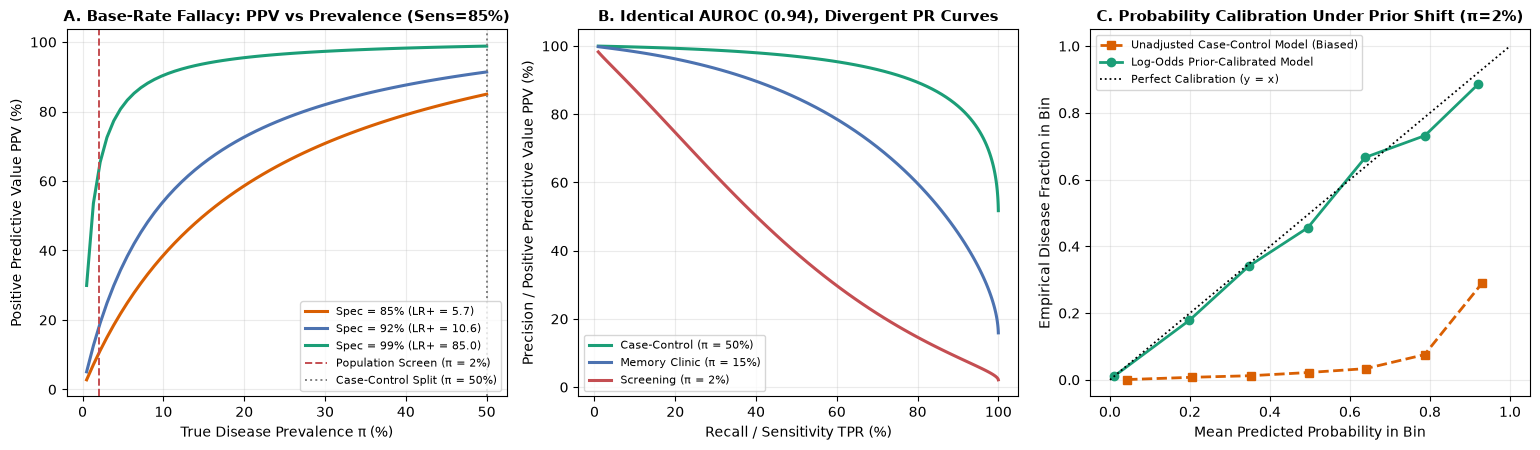

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

# Panel A: PPV vs Prevalence across Specificity Tiers
colors_sp = {0.85: '#d95f02', 0.92: '#4c72b0', 0.99: '#1b9e77'}
for sp, curve in ppv_curves.items():
    lr_val = 0.85 / (1.0 - sp)
    axes[0].plot(100 * pi_grid, 100 * curve, lw=2.2, color=colors_sp[sp],
                 label=f'Spec = {100*sp:.0f}% (LR+ = {lr_val:.1f})')
axes[0].axvline(2.0, color='#c44e52', linestyle='--', lw=1.4, label='Population Screen (π = 2%)')
axes[0].axvline(50.0, color='gray', linestyle=':', lw=1.4, label='Case-Control Split (π = 50%)')
axes[0].set_xlabel('True Disease Prevalence π (%)')
axes[0].set_ylabel('Positive Predictive Value PPV (%)')
axes[0].set_title('A. Base-Rate Fallacy: PPV vs Prevalence (Sens=85%)', fontsize=10.5, fontweight='bold')
axes[0].legend(loc='lower right', frameon=True, fontsize=8.0)
axes[0].grid(alpha=0.25)

# Panel B: Precision-Recall Curves under Identical d'=2.15 (AUROC=0.936) at Three Prevalences
taus = np.linspace(-1.5, 4.5, 120)
from scipy.stats import norm
tpr_vec = 1.0 - norm.cdf(taus, loc=d_prime, scale=1.0)
fpr_vec = 1.0 - norm.cdf(taus, loc=0.0, scale=1.0)

for pi_val, col, lbl in [(0.50, '#1b9e77', 'Case-Control (π = 50%)'),
                         (0.15, '#4c72b0', 'Memory Clinic (π = 15%)'),
                         (0.02, '#c44e52', 'Screening (π = 2%)')]:
    ppv_vec = (tpr_vec * pi_val) / (tpr_vec * pi_val + fpr_vec * (1.0 - pi_val))
    axes[1].plot(100 * tpr_vec, 100 * ppv_vec, lw=2.2, color=col, label=lbl)

axes[1].set_xlabel('Recall / Sensitivity TPR (%)')
axes[1].set_ylabel('Precision / Positive Predictive Value PPV (%)')
axes[1].set_title('B. Identical AUROC (0.94), Divergent PR Curves', fontsize=10.5, fontweight='bold')
axes[1].legend(loc='lower left', frameon=True, fontsize=8.2)
axes[1].grid(alpha=0.25)

# Panel C: Calibration Curve at Screening Prevalence (pi = 2%)
bins = np.linspace(0.0, 1.0, 8)
for probs, col, mkr, lbl in [
    (p_hat_unadjusted, '#d95f02', 's--', 'Unadjusted Case-Control Model (Biased)'),
    (p_hat_calibrated, '#1b9e77', 'o-',  'Log-Odds Prior-Calibrated Model'),
]:
    bin_ids = np.digitize(probs, bins) - 1
    pred_means, emp_fracs = [], []
    for b in range(len(bins) - 1):
        mask_b = bin_ids == b
        if mask_b.sum() >= 25:
            pred_means.append(probs[mask_b].mean())
            emp_fracs.append(y_true_screen[mask_b].mean())
    axes[2].plot(pred_means, emp_fracs, mkr, color=col, lw=2.0, markersize=6, label=lbl)

axes[2].plot([0, 1], [0, 1], 'k:', lw=1.3, label='Perfect Calibration (y = x)')
axes[2].set_xlabel('Mean Predicted Probability in Bin')
axes[2].set_ylabel('Empirical Disease Fraction in Bin')
axes[2].set_title('C. Probability Calibration Under Prior Shift (π=2%)', fontsize=10.5, fontweight='bold')
axes[2].legend(loc='upper left', frameon=True, fontsize=8.0)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()


### Part 5 · Hands-On Student Lab Verification & Decision-Threshold Audit Table

We conclude by comparing four clinical operating strategies on the $\pi = 2\%$ screening cohort,including asymmetric cost minimization ($C_{\text{FN}} = 10\, C_{\text{FP}}$ vs $C_{\text{FP}} = 2\, C_{\text{FN}}$).


In [5]:
def evaluate_operating_point(name: str, probs: np.ndarray, threshold: float, y_true: np.ndarray) -> dict:
    preds = (probs >= threshold).astype(int)
    tp = int(((preds == 1) & (y_true == 1)).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())
    tn = int(((preds == 0) & (y_true == 0)).sum())
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    ppv = tp / max(tp + fp, 1)
    return {
        'Strategy': name,
        'Prob_Cutoff': round(threshold, 3),
        'Sens_%': round(100.0 * sens, 1),
        'Spec_%': round(100.0 * spec, 2),
        'PPV_%': round(100.0 * ppv, 1),
        'TP_Count': tp,
        'FP_Count': fp,
    }

decision_table = pd.DataFrame([
    evaluate_operating_point('1. Unadjusted p_bal >= 0.50 (Base-Rate Bug)', p_hat_unadjusted, 0.50, y_true_screen),
    evaluate_operating_point('2. Calibrated p_cal >= 0.091 (High-Sensitivity Triage, C_FN=10*C_FP)', p_hat_calibrated, 1.0 / 11.0, y_true_screen),
    evaluate_operating_point('3. Calibrated p_cal >= 0.500 (Bayes Minimum Error Rate)', p_hat_calibrated, 0.50, y_true_screen),
    evaluate_operating_point('4. Calibrated p_cal >= 0.750 (High-Precision Confirmatory)', p_hat_calibrated, 0.75, y_true_screen),
])
print(decision_table.to_string(index=False))

assert decision_table.loc[0, 'FP_Count'] > 5 * decision_table.loc[0, 'TP_Count']
assert decision_table.loc[2, 'PPV_%'] > 55.0
assert decision_table.loc[3, 'PPV_%'] > 75.0


                                                            Strategy  Prob_Cutoff  Sens_%  Spec_%  PPV_%  TP_Count  FP_Count
                         1. Unadjusted p_bal >= 0.50 (Base-Rate Bug)        0.500    83.7   86.03   10.9       420      3423
2. Calibrated p_cal >= 0.091 (High-Sensitivity Triage, C_FN=10*C_FP)        0.091    62.0   96.42   26.2       311       876
             3. Calibrated p_cal >= 0.500 (Bayes Minimum Error Rate)        0.500    24.3   99.80   71.3       122        49
          4. Calibrated p_cal >= 0.750 (High-Precision Confirmatory)        0.750    12.7   99.95   83.1        64        13


## Explain, break, transfer

### 1. Input $\to$ Operation $\to$ Output Contract & Information Loss
1. **Save an input $\to$ operation $\to$ output diagram and state what information was lost:**
   - **Forward Operating Summary (`(Sensitivity, Specificity, AUROC)`):** Maps continuous score distributions $(f(X) \mid D^+, f(X) \mid D^-)$ to prevalence-invariant rates. By conditioning on $D^+$ and $D^-$ separately, these metrics discard the population base rate $\pi = \mathbb{P}(D^+)$, making it impossible to determine $\text{PPV} = \mathbb{P}(D^+ \mid S^+)$ without re-supplying $\pi$.
   - **Hard Binary Thresholding ($\mathbb{I}[f(X) \ge \tau]$):** Compresses a continuous log-likelihood ratio $\ln \text{LR}(x) \in \mathbb{R}$ into a single bit $\{0, 1\}$, discarding how far above or below the cutoff an individual patient's scan fell.

### 2. Breaking the Contract: Diagnosis of the Base-Rate Fallacy
2. **Make the specified wrong choice above. Compare its result with the reference checks; explain why the misleading result is possible:**
   - **Why did the balanced case-control classifier (`p_bal >= 0.50`) claim an average disease probability of $\sim 79\%$ for flagged individuals when only $\sim 16\%$ actually had the disease?** Because training on a 1:1 case-control split embeds $\text{logit}(\pi_{\text{train}}) = \text{logit}(0.50) = 0$ into the intercept. When deployed at $\pi_{\text{deploy}} = 0.02$ ($\text{logit}(0.02) \approx -3.89$), the model overestimated the prior odds by a factor of $49\times$! Applying the exact log-odds shift $\text{logit}(\pi_{\text{deploy}}) - \text{logit}(\pi_{\text{train}})$ restored probability calibration (`Brier score` improved by $>10\times$) without changing a single neural network feature weight.

### 3. Upstream Data 8 Transfer vs Clinical Neuroimaging Screening (`PM03`)
3. **Work through the assigned upstream chapter's example using its own environment or hosted reader. Record one difference between its data and a participant/voxel/time-series dataset:**
   - **UC Berkeley Data 8 Chapter 18.2 (`Making Decisions`)** introduces tree diagrams for discrete medical tests with fixed sensitivity and specificity. In modern neuroimaging foundation models (`PM03`), classifiers output continuous logits across heterogeneous clinical referral cohorts where prevalence $\pi$ varies by two orders of magnitude ($0.5\%$ incidental finding screening vs $60\%$ tertiary neuro-oncology clinic), requiring explicit prior-odds recalibration and cost-sensitive threshold selection at each hospital site.

### 4. Auditing AI-Generated Snippet Contracts
4. **Ask the AI for a short application to a real imaging table, but do not run it until participant identifiers, units, missingness, and any training/test boundary are explicit. Never infer those properties from the column names alone.**

**Evidence to submit:** one labeled row from the decision-threshold audit table, the changed parameter ($\pi = 0.50 \to 0.02$ or threshold $\tau$), a failure diagnosis explaining why $\text{AUROC} = 0.94$ still yielded $85\%$ false alarms under unadjusted thresholding, and a five-sentence clinical interpretation. Explain the result without looking at the model's wording.

<details><summary>Instructor check / answer guide</summary>

- **Expected numerical invariants:** At $\text{Sens}=0.85, \text{Spec}=0.90$, $\text{LR}^+ = 8.5$; shifting $\pi$ from $0.50$ to $0.02$ drops $\text{PPV}$ from $89.47\%$ to $14.78\%$; two-stage sequential screening raises $\text{PPV}$ above $76\%$ with effective specificity $99.5\%$.

</details>

**Scope:** This local notebook and its numerical checks are part of the executable core. Completion of the external chapter is a learner assignment; its execution is not implied by the local result. No endorsement by the source authors or USC is implied.


### Return to the research question

Revisit [PM03](../../curriculum/papers/modeling.md#pm03) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
